# Part II: Embedding Variants and Ablation (30 pts)

Modify the embedding layer in **all three neural language models** (RNN, LSTM, Transformer).

3 embedding variants × 3 models = 9 combinations:
1. **Scratch** — trainable embeddings learned from scratch
2. **W2V frozen** — Word2Vec trained on AG News corpus, frozen
3. **GloVe pretrained frozen** — glove-wiki-gigaword-100, frozen

Compare: performance (perplexity), training stability, convergence speed.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from src.utils import load_config, set_seed, get_device, compute_perplexity
from src.utils import count_parameters, MODEL_COLORS
from src.data import prepare_data, build_lm_dataloaders
from src.rnn_lm import RNNLM
from src.lstm_lm import LSTMLM
from src.transformer_lm import TransformerLM
from src.embeddings import get_embedding_layer
from src.train import train_lm

config = load_config('../configs/default.yaml')
set_seed(config['seed'])
device = get_device()
print(f'Device: {device}')

Device: cuda


In [2]:
data = prepare_data(config)
vocab = data['vocab']

cfg_data = config['data']
cfg_train = config['training']
cfg_model = config['model']
cfg_tf = config['transformer']

train_dl, val_dl, test_dl = build_lm_dataloaders(
    data,
    batch_size=cfg_train['batch_size'],
    max_seq_len=cfg_data['max_seq_len'],
    num_workers=cfg_train['num_workers'],
)

print(f'Vocab size: {len(vocab)}')
print(f'Train batches: {len(train_dl)}, Val: {len(val_dl)}, Test: {len(test_dl)}')

Loading AG News dataset...
Tokenizing...
Building vocabulary...
  Vocabulary size: 20000
Encoding sequences...
Vocab size: 20000
Train batches: 1500, Val: 188, Test: 188


## Model factory

Helper to create each model type with a given embedding layer.

In [3]:
def make_model(model_type, embedding_layer):
    """Create a fresh model of the given type with the specified embedding layer."""
    common = dict(
        vocab_size=len(vocab),
        embed_dim=cfg_model['embed_dim'],
        num_layers=cfg_model['num_layers'],
        dropout=cfg_model['dropout'],
        embedding_layer=embedding_layer,
    )
    if model_type == 'rnn':
        return RNNLM(hidden_dim=cfg_model['hidden_dim'], **common)
    elif model_type == 'lstm':
        return LSTMLM(hidden_dim=cfg_model['hidden_dim'], **common)
    elif model_type == 'transformer':
        return TransformerLM(
            n_heads=cfg_tf['n_heads'],
            d_ff=cfg_tf['d_ff'],
            max_seq_len=cfg_data['max_seq_len'],
            **common,
        )
    else:
        raise ValueError(f'Unknown model type: {model_type}')

## Pre-train Word2Vec once (reused across all models)

Word2Vec and GloVe loading are expensive — we cache the weight matrices so each model just copies them.

In [ ]:
# Pre-build embedding weight matrices once, reuse for each model

print('=== Pre-building embedding weight matrices ===')

# 1) Word2Vec
print('\n--- Word2Vec ---')
w2v_emb = get_embedding_layer(
    variant='w2v_frozen',
    vocab=vocab,
    embed_dim=cfg_model['embed_dim'],
    train_token_lists=data['train_token_lists'],
    config=config,
)
w2v_weights = w2v_emb.weight.data.clone()
print(f'  W2V weight shape: {w2v_weights.shape}')

# 2) Pretrained GloVe (100-dim, matches embed_dim exactly)
print('\n--- Pretrained GloVe ---')
glove_emb = get_embedding_layer(
    variant='glove_pretrained_frozen',
    vocab=vocab,
    embed_dim=cfg_model['embed_dim'],
    train_token_lists=data['train_token_lists'],
    config=config,
)
glove_weights = glove_emb.weight.data.clone()
print(f'  GloVe weight shape: {glove_weights.shape}')

print('\nDone. Cached weight matrices for reuse.')

=== Pre-building embedding weight matrices ===

--- Word2Vec ---
  Training Word2Vec (dim=100, window=5)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

  Word2Vec coverage: 19996/20000 (100.0%)
  W2V weight shape: torch.Size([20000, 100])

--- Pretrained GloVe ---
  Loading pretrained GloVe (glove-wiki-gigaword-100)...
  GloVe coverage: 19768/20000 (98.8%)
  GloVe weight shape: torch.Size([20000, 100])

Done. Cached weight matrices for reuse.


## Run ablation: 3 models × 3 embedding variants = 9 runs

In [5]:
import torch.nn as nn

model_types = config['embedding_ablation']['models']  # ['rnn', 'lstm', 'transformer']
variants = config['embedding_ablation']['variants']    # ['scratch', 'w2v_frozen', 'glove_pretrained_frozen']

ablation_results = {}

for model_type in model_types:
    for variant in variants:
        run_name = f'{model_type}_{variant}'
        print(f'\n{"="*60}')
        print(f'{run_name}')
        print(f'{"="*60}')
        
        set_seed(config['seed'])  # reset seed for fair comparison
        
        # Create embedding layer for this variant
        if variant == 'scratch':
            emb_layer = nn.Embedding(len(vocab), cfg_model['embed_dim'], padding_idx=0)
        elif variant == 'w2v_frozen':
            emb_layer = nn.Embedding.from_pretrained(w2v_weights.clone(), freeze=True, padding_idx=0)
        elif variant == 'glove_pretrained_frozen':
            emb_layer = nn.Embedding.from_pretrained(glove_weights.clone(), freeze=True, padding_idx=0)
        else:
            raise ValueError(f'Unknown variant: {variant}')
        
        trainable_emb = emb_layer.weight.requires_grad
        print(f'  Embedding: dim={emb_layer.weight.shape[1]}, trainable={trainable_emb}')
        
        # Create model
        model = make_model(model_type, emb_layer)
        
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = count_parameters(model)
        print(f'  Total params: {total_params:,}, Trainable: {trainable_params:,}')
        
        # Train
        model, history = train_lm(
            model, train_dl, val_dl, device, config,
            model_name=run_name,
        )
        
        # Test perplexity
        test_ppl = compute_perplexity(model, test_dl, device)
        epoch1_ppl = history['val_perplexity'][0] if history['val_perplexity'] else float('inf')
        
        ablation_results[run_name] = {
            'model_type': model_type,
            'variant': variant,
            'history': history,
            'test_perplexity': test_ppl,
            'trainable_params': trainable_params,
            'total_params': total_params,
            'epoch1_ppl': epoch1_ppl,
            'trainable_emb': trainable_emb,
        }
        
        print(f'\n  Epoch-1 val PPL: {epoch1_ppl:.2f}')
        print(f'  Best val PPL:   {history["best_val_perplexity"]:.2f}')
        print(f'  Test PPL:       {test_ppl:.2f}')
        print(f'  Epochs trained: {len(history["val_perplexity"])}')
        print(f'  Total time:     {history["total_time"]:.1f}s')


rnn_scratch
  Embedding: dim=100, trainable=True
  Total params: 4,060,400, Trainable: 4,060,400

Training: rnn_scratch
  Trainable parameters: 4,060,400
  Device: cuda


  Epoch 1: train_loss=6.1481, val_ppl=252.80, time=93.3s
Model saved to outputs/models\rnn_scratch_best.pt


  Epoch 2: train_loss=5.4693, val_ppl=191.06, time=92.9s
Model saved to outputs/models\rnn_scratch_best.pt


  Epoch 3: train_loss=5.2711, val_ppl=163.45, time=93.4s
Model saved to outputs/models\rnn_scratch_best.pt


  Epoch 4: train_loss=5.1327, val_ppl=144.97, time=93.3s
Model saved to outputs/models\rnn_scratch_best.pt


...

  Epoch 16: train_loss=4.2055, val_ppl=62.73, time=106.1s
Model saved to outputs/models\transformer_glove_pretrained_frozen_best.pt


  Epoch 17: train_loss=4.1974, val_ppl=62.45, time=106.4s
Model saved to outputs/models\transformer_glove_pretrained_frozen_best.pt


  Epoch 18: train_loss=4.1900, val_ppl=61.95, time=107.0s
Model saved to outputs/models\transformer_glove_pretrained_frozen_best.pt


  Epoch 19: train_loss=4.1829, val_ppl=61.73, time=108.1s
Model saved to outputs/models\transformer_glove_pretrained_frozen_best.pt


  Epoch 20: train_loss=4.1769, val_ppl=61.39, time=104.6s
Model saved to outputs/models\transformer_glove_pretrained_frozen_best.pt

Best val perplexity: 61.39
Total training time: 2163.3s

  Epoch-1 val PPL: 157.18
  Best val PPL:   61.39
  Test PPL:       60.76
  Epochs trained: 20
  Total time:     2163.3s


## Summary Table

In [10]:
rows = []
for run_name, result in ablation_results.items():
    rows.append({
        'Model': result['model_type'].upper(),
        'Embedding': result['variant'],
        'Trainable Params': f"{result['trainable_params']:,}",
        'Epoch-1 PPL': f"{result['epoch1_ppl']:.2f}",
        'Best Val PPL': f"{result['history']['best_val_perplexity']:.2f}",
        'Test PPL': f"{result['test_perplexity']:.2f}",
        'Epochs': len(result['history']['val_perplexity']),
        'Time (s)': f"{result['history']['total_time']:.1f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

      Model               Embedding Trainable Params Epoch-1 PPL Best Val PPL Test PPL  Epochs Time (s)
        RNN                 scratch        4,060,400      252.80        97.46    96.26      20   1871.1
        RNN              w2v_frozen        2,060,400      242.86        94.18    93.13      20   1849.0
        RNN glove_pretrained_frozen        2,060,400      239.55       112.84   111.39      20   1849.5
       LSTM                 scratch        4,181,600      358.39        79.01    78.00      20   1986.1
       LSTM              w2v_frozen        2,181,600      464.46        75.96    75.06      20   1958.2
       LSTM glove_pretrained_frozen        2,181,600      456.77        84.28    83.12      20   1959.2
TRANSFORMER                 scratch        4,275,600      184.57        54.42    53.83      20   2097.7
TRANSFORMER              w2v_frozen        2,275,600      164.01        58.37    57.65      20   2116.1
TRANSFORMER glove_pretrained_frozen        2,275,600      157.18

## Convergence Plots

One subplot per model, showing val perplexity curves for each embedding variant.

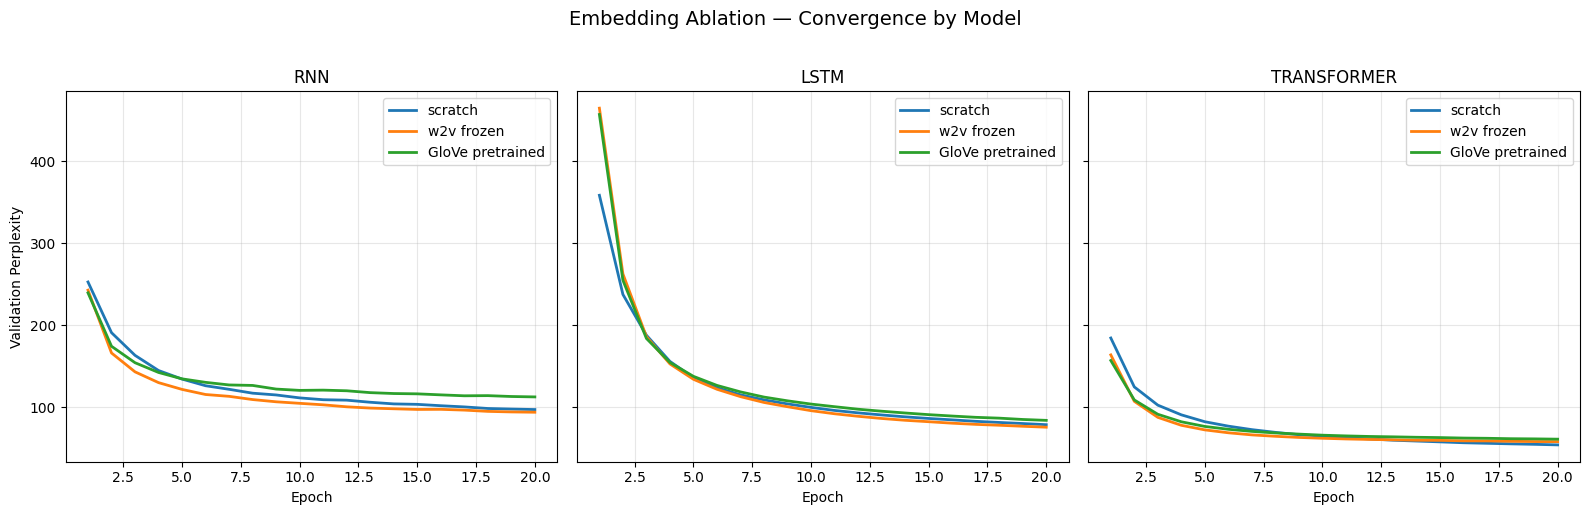

In [11]:
model_types_list = config['embedding_ablation']['models']
variant_colors = {'scratch': '#1f77b4', 'w2v_frozen': '#ff7f0e', 'glove_pretrained_frozen': '#2ca02c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, mt in zip(axes, model_types_list):
    for variant in variants:
        run_name = f'{mt}_{variant}'
        if run_name in ablation_results:
            vals = ablation_results[run_name]['history']['val_perplexity']
            label = variant.replace('_', ' ').replace('glove pretrained frozen', 'GloVe pretrained')
            ax.plot(range(1, len(vals) + 1), vals, label=label,
                    color=variant_colors.get(variant), linewidth=2)
    ax.set_title(mt.upper())
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Validation Perplexity')
fig.suptitle('Embedding Ablation — Convergence by Model', fontsize=14, y=1.02)
plt.tight_layout()

save_path = '../outputs/plots/part2_convergence.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

## Cross-model comparison: same embedding, different models

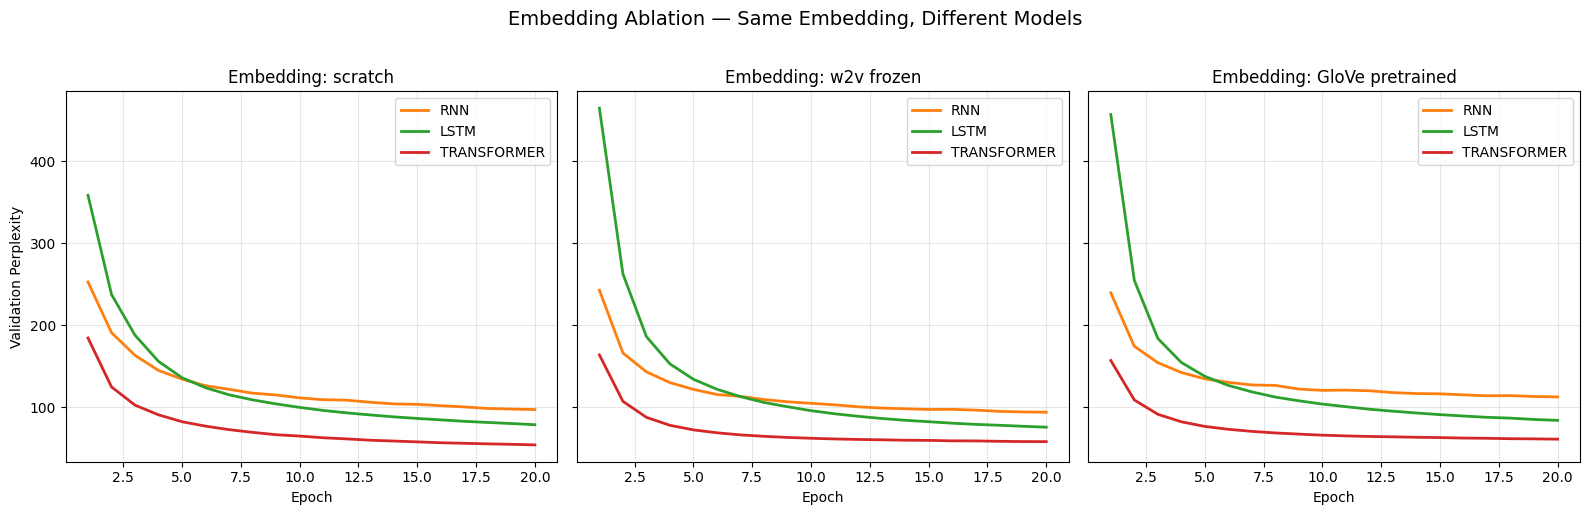

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, variant in zip(axes, variants):
    for mt in model_types_list:
        run_name = f'{mt}_{variant}'
        if run_name in ablation_results:
            vals = ablation_results[run_name]['history']['val_perplexity']
            ax.plot(range(1, len(vals) + 1), vals, label=mt.upper(),
                    color=MODEL_COLORS.get(mt), linewidth=2)
    label = variant.replace('_', ' ').replace('glove pretrained frozen', 'GloVe pretrained')
    ax.set_title(f'Embedding: {label}')
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Validation Perplexity')
fig.suptitle('Embedding Ablation — Same Embedding, Different Models', fontsize=14, y=1.02)
plt.tight_layout()

save_path = '../outputs/plots/part2_cross_model.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

## Epoch-1 Perplexity: Cold Start vs Warm Start

In [13]:
print('--- Epoch-1 Perplexity (Convergence Speed Signal) ---')
print(f'{"Run":<35s} {"Epoch-1":>10s} {"Best":>10s} {"Gap":>10s}')
print('-' * 65)
for run_name, result in ablation_results.items():
    e1 = result['epoch1_ppl']
    best = result['history']['best_val_perplexity']
    gap = e1 - best
    print(f'{run_name:<35s} {e1:>10.2f} {best:>10.2f} {gap:>10.2f}')

--- Epoch-1 Perplexity (Convergence Speed Signal) ---
Run                                    Epoch-1       Best        Gap
-----------------------------------------------------------------
rnn_scratch                             252.80      97.46     155.34
rnn_w2v_frozen                          242.86      94.18     148.68
rnn_glove_pretrained_frozen             239.55     112.84     126.71
lstm_scratch                            358.39      79.01     279.38
lstm_w2v_frozen                         464.46      75.96     388.51
lstm_glove_pretrained_frozen            456.77      84.28     372.49
transformer_scratch                     184.57      54.42     130.16
transformer_w2v_frozen                  164.01      58.37     105.65
transformer_glove_pretrained_frozen     157.18      61.39      95.79


## Analysis

**Best embedding per model (test PPL):**
- RNN: W2V frozen (93.1) > scratch (96.3) > GloVe (111.4)
- LSTM: W2V frozen (75.1) > scratch (78.0) > GloVe (83.1)
- Transformer: scratch (53.8) > W2V frozen (57.7) > GloVe (60.8)

**Convergence speed (epoch-1 PPL):**
For RNN and Transformer, pretrained variants start with lower epoch-1 perplexity (RNN: scratch 253, W2V 243, GloVe 240; Transformer: scratch 185, W2V 164, GloVe 157), confirming a warm-start benefit from meaningful initial embeddings.

LSTM shows the opposite pattern: scratch (358) starts well below frozen variants (W2V 464, GloVe 457). This is likely because LSTM's input/forget/output gates are initialized for random embeddings — frozen pretrained embeddings have a different scale and distribution that the gates need several epochs to adapt to, causing higher initial perplexity despite the embeddings themselves being more informative.

**Why W2V beats GloVe across all models:**
W2V was self-trained on AG News and achieves near-perfect vocabulary coverage (99.98%), while GloVe (trained on Wikipedia+Gigaword) covers 98.8%. More importantly, W2V embeddings capture domain-specific word relationships from news articles, while GloVe encodes general-purpose semantics. The domain match matters more than the scale of pretraining data.

**Why scratch wins for Transformer but not RNN/LSTM:**
The Transformer's self-attention mechanism can reshape token representations at every layer based on full-sequence context — it effectively learns task-specific embeddings through training. With 2M extra trainable parameters in the embedding layer, scratch Transformer has more capacity to specialize. RNN and LSTM, which process tokens sequentially through a fixed-size hidden state, benefit more from starting with good embeddings since they have less ability to compensate for poor initializations.

**Frozen variants have fewer trainable params** (2.06–2.28M vs 4.06–4.28M) since the 2M embedding parameters are excluded from gradient updates. Despite this, W2V frozen matches or beats scratch for RNN and LSTM, suggesting that domain-matched pretrained embeddings are more effective than learning embeddings from scratch on this dataset size (~96K training documents).